<h1 style="color:#FF1493;"> Analysis of Sentiment-Associated Words in Persian SnappFood Reviews </h1>

<h2 style="color:#00BFC4;"> Data Analysis Final Project - Ala A. </h2>

### Project objective

The purpose of this project is to analyse Persian customer comments from
SnappFood and identify the words and phrases most strongly associated with
positive (`HAPPY`) and negative (`SAD`) reviews.

The analysis will include:

- Data inspection and cleaning
- Persian text normalization
- Stopword removal
- Word-frequency analysis
- Positive and negative word association
- Bigram and phrase analysis
- Data visualization
- Interpretation of the results

<h1 style="color:#FF1493;">Step 2: Loading and Inspecting the Dataset</h1>

<h2 style="color:#00BFC4;">Importing the Required Libraries</h2>

<p>
In this section, the required Python libraries are imported, the SnappFood
dataset is loaded, and its basic structure is examined.
</p>

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display more text from long Persian comments
pd.set_option("display.max_colwidth", 200)

# Display all dataset columns
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


<h2 style="color:#00BFC4;">Loading the SnappFood Dataset</h2>

<p>
The dataset file uses tab characters as column separators rather than
ordinary commas. Therefore, the <code>sep="\t"</code> argument was used
when reading the file with pandas.
</p>

In [2]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path.cwd() / "data" / "snappfood_comments.csv"

try:
    df = pd.read_csv(
        DATA_PATH,
        sep="\t",
        encoding="utf-8-sig",
        low_memory=False
    )

    print("Dataset loaded successfully.")

except FileNotFoundError:
    print(f"File not found: {DATA_PATH}")

except pd.errors.ParserError as error:
    print("The file could not be parsed.")
    print(error)

except UnicodeDecodeError as error:
    print("The file encoding could not be read.")
    print(error)

Dataset loaded successfully.


In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

Rows: 70,000
Columns: 4

Column names:
['Unnamed: 0', 'comment', 'label', 'label_id']


In [4]:
df.head()

,Unnamed: 0,comment,label,label_id
0,NaN,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1.0
1,NaN,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون,HAPPY,0.0
2,NaN,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1.0
3,NaN,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,0.0
4,NaN,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0.0


In [5]:
df.shape

(70000, 4)

In [6]:
df.columns.tolist()

['Unnamed: 0', 'comment', 'label', 'label_id']

<h1 style="color:#FF1493;">Step 3: Initial Data Quality Assessment</h1>

<h2 style="color:#00BFC4;">Removing Unnecessary Columns</h2>

<p>
Before analysing the comments, the dataset structure is cleaned and checked
for missing values, duplicate records, invalid labels, and class imbalance.
</p>

In [7]:
# Remove the automatically saved index column
df = df.drop(columns=["Unnamed: 0"])

print("Updated dataset shape:", df.shape)
print("Remaining columns:", df.columns.tolist())

Updated dataset shape: (70000, 3)
Remaining columns: ['comment', 'label', 'label_id']


In [8]:
df.head()

,comment,label,label_id
0,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1.0
1,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون,HAPPY,0.0
2,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1.0
3,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,0.0
4,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0.0


<h2 style="color:#00BFC4;">Dataset Information</h2>

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   comment   70000 non-null  str    
 1   label     70000 non-null  str    
 2   label_id  69480 non-null  float64
dtypes: float64(1), str(2)
memory usage: 12.5 MB


<h2 style="color:#00BFC4;">Missing Value Analysis</h2>

<p>
Missing values are checked because comments without text or labels cannot
be used reliably in sentiment analysis.
</p>

In [10]:
missing_values = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

missing_values

,Missing Count,Missing Percentage
comment,0,0.00
label,0,0.00
label_id,520,0.74


In [11]:
print("Total missing values:", df.isna().sum().sum())

Total missing values: 520


In [12]:
empty_comments = (
    df["comment"]
    .fillna("")
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print("Number of empty comments:", empty_comments)

Number of empty comments: 0


<h2 style="color:#00BFC4;">Sentiment Label Inspection</h2>

In [13]:
print("Unique text labels:")
print(df["label"].unique())

print("\nUnique numerical labels:")
print(df["label_id"].unique())

Unique text labels:
<ArrowStringArray>
['SAD', 'HAPPY', '1', '0']
Length: 4, dtype: str

Unique numerical labels:
[ 1.  0. nan]


In [14]:
label_mapping = (
    df[["label", "label_id"]]
    .drop_duplicates()
    .sort_values("label_id")
)

label_mapping

,label,label_id
1,HAPPY,0.0
0,SAD,1.0
21,1,NaN
243,0,NaN


In [15]:
label_counts = df["label"].value_counts()

label_counts

label
HAPPY    34916
SAD      34564
1          436
0           84
Name: count, dtype: int64

In [16]:
label_distribution = pd.DataFrame({
    "Count": df["label"].value_counts(),
    "Percentage": (
        df["label"].value_counts(normalize=True) * 100
    ).round(2)
})

label_distribution

,Count,Percentage
label,,
HAPPY,34916,49.88
SAD,34564,49.38
1,436,0.62
0,84,0.12


<h2 style="color:#00BFC4;">Sentiment Distribution Visualization</h2>

<p>
The following bar chart compares the number of positive and negative comments
in the dataset.
</p>

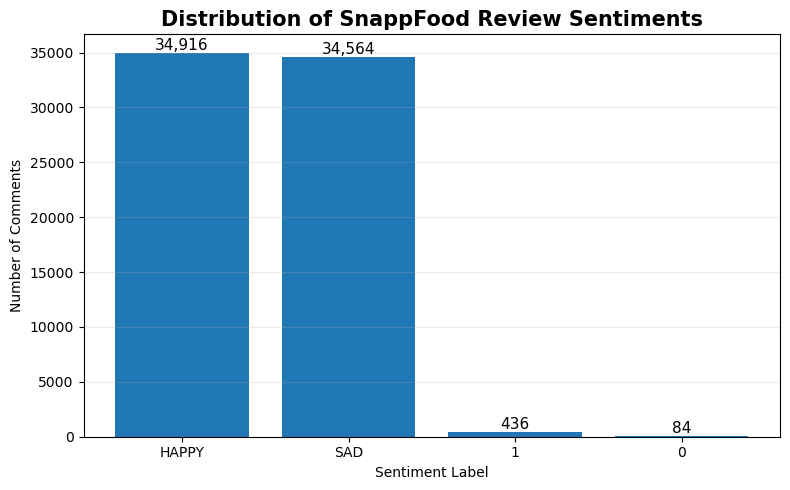

In [17]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    label_counts.index,
    label_counts.values
)

plt.title(
    "Distribution of SnappFood Review Sentiments",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Sentiment Label")
plt.ylabel("Number of Comments")

plt.grid(axis="y", alpha=0.25)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 300,
        f"{int(height):,}",
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

<h2 style="color:#00BFC4;">Duplicate Record Analysis</h2>

<p>
Duplicate comments may influence word frequencies by causing some expressions
to be counted more often than they should be. They are inspected before any
records are removed.
</p>

In [18]:
complete_duplicate_count = df.duplicated().sum()

print("Number of completely duplicated rows:", complete_duplicate_count)

Number of completely duplicated rows: 518


In [19]:
duplicate_comment_count = df.duplicated(
    subset=["comment"],
    keep=False
).sum()

print(
    "Number of rows containing duplicated comment text:",
    duplicate_comment_count
)

Number of rows containing duplicated comment text: 520


In [20]:
duplicate_comments = (
    df[df.duplicated(subset=["comment"], keep=False)]
    .sort_values("comment")
)

duplicate_comments.head(20)

,comment,label,label_id
243,HAPPY,0,NaN
415,HAPPY,0,NaN
2173,HAPPY,0,NaN
3905,HAPPY,0,NaN
5114,HAPPY,0,NaN
5458,HAPPY,0,NaN
5523,HAPPY,0,NaN
6535,HAPPY,0,NaN
7674,HAPPY,0,NaN
9418,HAPPY,0,NaN


In [21]:
label_count_per_comment = (
    df.groupby("comment")["label"]
    .nunique()
)

conflicting_comments = label_count_per_comment[
    label_count_per_comment > 1
]

print(
    "Number of identical comments with conflicting labels:",
    len(conflicting_comments)
)

Number of identical comments with conflicting labels: 0


In [22]:
if len(conflicting_comments) > 0:
    conflicting_examples = df[
        df["comment"].isin(conflicting_comments.index)
    ].sort_values("comment")

    display(conflicting_examples.head(20))
else:
    print("No conflicting labels were found.")

No conflicting labels were found.


In [23]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Total missing values",
        "Empty comments",
        "Completely duplicated rows",
        "Rows with duplicated comment text",
        "Comments with conflicting labels"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.isna().sum().sum(),
        empty_comments,
        complete_duplicate_count,
        duplicate_comment_count,
        len(conflicting_comments)
    ]
})

quality_summary

,Metric,Value
0,Number of rows,70000
1,Number of columns,3
2,Total missing values,520
3,Empty comments,0
4,Completely duplicated rows,518
5,Rows with duplicated comment text,520
6,Comments with conflicting labels,0


In [24]:
df.isna().sum()

comment       0
label         0
label_id    520
dtype: int64

In [25]:
label_mapping

,label,label_id
1,HAPPY,0.0
0,SAD,1.0
21,1,NaN
243,0,NaN


In [26]:
label_distribution

,Count,Percentage
label,,
HAPPY,34916,49.88
SAD,34564,49.38
1,436,0.62
0,84,0.12


In [27]:
quality_summary

,Metric,Value
0,Number of rows,70000
1,Number of columns,3
2,Total missing values,520
3,Empty comments,0
4,Completely duplicated rows,518
5,Rows with duplicated comment text,520
6,Comments with conflicting labels,0


<h1 style="color:#FF1493;">Step 4: Cleaning the Dataset</h1>

<h2 style="color:#00BFC4;">Removing Invalid and Duplicate Records</h2>

<p>
Rows with invalid sentiment labels or missing numerical labels are removed.
Repeated comment texts are also removed to prevent duplicate reviews from
distorting the word-frequency analysis.
</p>

In [28]:
# Keep only valid labelled comments and remove duplicate texts
original_size = len(df)

df = (
    df[df["label"].isin(["HAPPY", "SAD"])]
    .dropna(subset=["comment", "label_id"])
    .drop_duplicates(subset=["comment"])
    .reset_index(drop=True)
)

df["label_id"] = df["label_id"].astype(int)

print(f"Original rows: {original_size:,}")
print(f"Clean rows: {len(df):,}")
print(f"Removed rows: {original_size - len(df):,}")

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate comments:", df["comment"].duplicated().sum())

print("\nSentiment distribution:")
print(df["label"].value_counts())

Original rows: 70,000
Clean rows: 69,480
Removed rows: 520

Missing values:
comment     0
label       0
label_id    0
dtype: int64

Duplicate comments: 0

Sentiment distribution:
label
HAPPY    34916
SAD      34564
Name: count, dtype: int64


In [29]:
df.groupby("label")["label_id"].unique()

label
HAPPY    [0]
SAD      [1]
Name: label_id, dtype: object

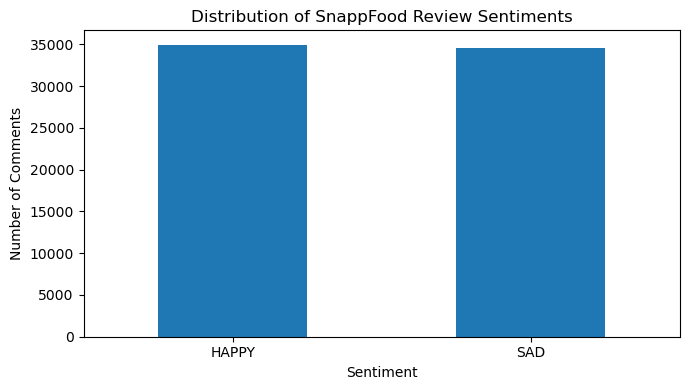

In [30]:
sentiment_counts = df["label"].value_counts()

sentiment_counts.plot(
    kind="bar",
    figsize=(7, 4),
    title="Distribution of SnappFood Review Sentiments"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<h1 style="color:#FF1493;">Step 5: Persian Text Preprocessing</h1>

<h2 style="color:#00BFC4;">Normalizing and Tokenizing the Comments</h2>

<p>
Persian comments may contain different forms of the same character,
punctuation, links, numbers, emojis, and informal spellings. The comments
are normalized before their sentiment-related words are counted.
</p>

In [32]:
import re
import unicodedata

# Common words that do not provide useful sentiment information
stopwords = {
    "و", "در", "به", "از", "که", "این", "آن", "را", "با", "برای",
    "تا", "یا", "اما", "ولی", "اگر", "چون", "چه", "هر", "هم",
    "همه", "یک", "دو", "روی", "تو", "من", "ما", "شما", "او",
    "آنها", "اینا", "اونا", "اون", "یه", "رو", "برا", "واسه",
    "است", "هست", "هستم", "هستند", "بود", "بوده", "شد", "شده",
    "می", "شود", "کرد", "کرده", "کنه", "کنند", "داشت", "دارد",
    "دارم", "دارند", "خود", "دیگه", "دیگر", "فقط", "مثل"
}

def normalize_persian(text):
    text = unicodedata.normalize("NFKC", str(text))

    # Normalize common Arabic characters
    text = text.translate(str.maketrans({
        "ي": "ی",
        "ى": "ی",
        "ك": "ک",
        "ۀ": "ه",
        "ة": "ه",
        "\u200c": " "   # Replace half-space with normal space
    }))

    # Remove links and Latin text
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[A-Za-z]+", " ", text)

    # Remove numbers
    text = re.sub(r"[0-9۰-۹٠-٩]+", " ", text)

    # Remove punctuation, emojis and other symbols
    text = "".join(
        character if character.isalpha() or character.isspace() else " "
        for character in text
    )

    # Reduce exaggerated letters: عاااالی → عالی
    text = re.sub(r"([آ-ی])\1{2,}", r"\1", text)

    # Remove extra spaces
    return re.sub(r"\s+", " ", text).strip()

In [33]:
# Normalize each original comment
df["normalized_comment"] = df["comment"].apply(normalize_persian)

# Split comments into words and remove stopwords
df["tokens"] = df["normalized_comment"].apply(
    lambda text: [
        word for word in text.split()
        if word not in stopwords and len(word) > 1
    ]
)

# Join the useful words for later analysis
df["clean_comment"] = df["tokens"].str.join(" ")

print("Preprocessing completed.")
print("Comments with no remaining keywords:",
      df["clean_comment"].eq("").sum())

Preprocessing completed.
Comments with no remaining keywords: 248


In [34]:
comparison = df[
    ["comment", "normalized_comment", "clean_comment"]
].sample(10, random_state=42)

comparison

,comment,normalized_comment,clean_comment
51167,غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است,غذا خیلی سرد بود در صورتیکه فاصله ما خیلی کم است,غذا خیلی سرد صورتیکه فاصله خیلی کم
22846,بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم,بهتره بتونیم ران یا سینه رو خودمون انتخاب کنیم,بهتره بتونیم ران سینه خودمون انتخاب کنیم
30915,غذا بد بود حالم خیییییلی بده. دل دردو دل پیچه. معلوم نیست چی توش ریختن. افتضاااااااااح بود. دوساعته ک حالم بده.,غذا بد بود حالم خیلی بده دل دردو دل پیچه معلوم نیست چی توش ریختن افتضاح بود دوساعته ک حالم بده,غذا بد حالم خیلی بده دل دردو دل پیچه معلوم نیست چی توش ریختن افتضاح دوساعته حالم بده
8011,با سلام سابق بر این بسته بندی از کیفیت بهتری برخوردار بود. ولی در حال حاضر ایراداتی وجود داره. به طور نمونه نوشابه قوطی فاقد نی هست، چنگال برای سرو سیب زمینی نداره، دستمال کاغذی هم در بسته بندی نیست.,با سلام سابق بر این بسته بندی از کیفیت بهتری برخوردار بود ولی در حال حاضر ایراداتی وجود داره به طور نمونه نوشابه قوطی فاقد نی هست چنگال برای سرو سیب زمینی نداره دستمال کاغذی هم در بسته بندی نیست,سلام سابق بر بسته بندی کیفیت بهتری برخوردار حال حاضر ایراداتی وجود داره طور نمونه نوشابه قوطی فاقد نی چنگال سرو سیب زمینی نداره دستمال کاغذی بسته بندی نیست
28563,سلام، خیلی ممنون و متشکرم,سلام خیلی ممنون و متشکرم,سلام خیلی ممنون متشکرم
11541,خیلی زود رسید و ممنون م ازشون,خیلی زود رسید و ممنون م ازشون,خیلی زود رسید ممنون ازشون
55679,مواد پیتزا بسیااار کم بود با اینکه قیمت اصلا پایین نیست. ولی کلا طعم پیتزا خوب و تازه بود,مواد پیتزا بسیار کم بود با اینکه قیمت اصلا پایین نیست ولی کلا طعم پیتزا خوب و تازه بود,مواد پیتزا بسیار کم اینکه قیمت اصلا پایین نیست کلا طعم پیتزا خوب تازه
53501,کیفیت زیاد خوب نبود،,کیفیت زیاد خوب نبود,کیفیت زیاد خوب نبود
13279,مرغی که واسه ما آوردن بو میداد انگار که مونده بود!,مرغی که واسه ما آوردن بو میداد انگار که مونده بود,مرغی آوردن بو میداد انگار مونده
28825,همه چی خوب بود. ولی اگه تخفیف نداشتم اصلا خرید نمی‌کردم چون گرونه برام:),همه چی خوب بود ولی اگه تخفیف نداشتم اصلا خرید نمی کردم چون گرونه برام,چی خوب اگه تخفیف نداشتم اصلا خرید نمی کردم گرونه برام


In [69]:
OUTPUT_PATH = Path.cwd() / "outputs" / "snappfood_cleaned.csv"

df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Processed dataset saved to:")

Processed dataset saved to:


<h1 style="color:#FF1493;">Step 6: Exploratory Text Analysis</h1>

<h2 style="color:#00BFC4;">Comment Length by Sentiment</h2>

<p>
Comment length is analysed to determine whether positive and negative
customers differ in how much they write.
</p>

In [36]:
# Keep the original dataset, but exclude comments with no useful tokens
analysis_df = df[df["tokens"].str.len() > 0].copy()

analysis_df["character_count"] = (
    analysis_df["normalized_comment"].str.len()
)

analysis_df["word_count"] = (
    analysis_df["normalized_comment"].str.split().str.len()
)

analysis_df["keyword_count"] = (
    analysis_df["tokens"].str.len()
)

print(f"Comments available for word analysis: {len(analysis_df):,}")

Comments available for word analysis: 69,232


In [37]:
length_summary = (
    analysis_df.groupby("label")[
        ["character_count", "word_count", "keyword_count"]
    ]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

length_summary

character_count                  word_count                  \
                 mean median min   max       mean median min  max   
label                                                               
HAPPY           75.43   56.0   4   902      16.21   12.0   1  201   
SAD            100.16   77.0  10  1650      21.41   16.0   3  352   

      keyword_count                  
               mean median min  max  
label                                
HAPPY         11.42    8.0   1  136  
SAD           15.30   12.0   1  259

In [38]:
simple_length_summary = (
    analysis_df.groupby("label")
    .agg(
        comments=("comment", "count"),
        average_words=("word_count", "mean"),
        median_words=("word_count", "median"),
        average_keywords=("keyword_count", "mean")
    )
    .round(2)
)

simple_length_summary

,comments,average_words,median_words,average_keywords
label,,,,
HAPPY,34770,16.21,12.0,11.42
SAD,34462,21.41,16.0,15.30


<h2 style="color:#00BFC4;">Average Number of Words</h2>

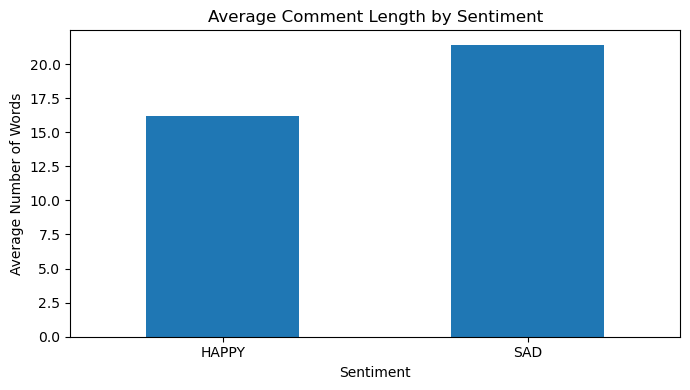

In [39]:
average_words = analysis_df.groupby("label")["word_count"].mean()

average_words.plot(
    kind="bar",
    figsize=(7, 4),
    title="Average Comment Length by Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

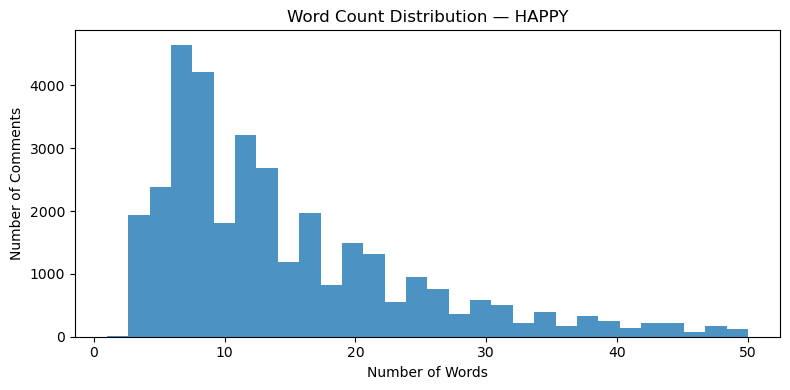

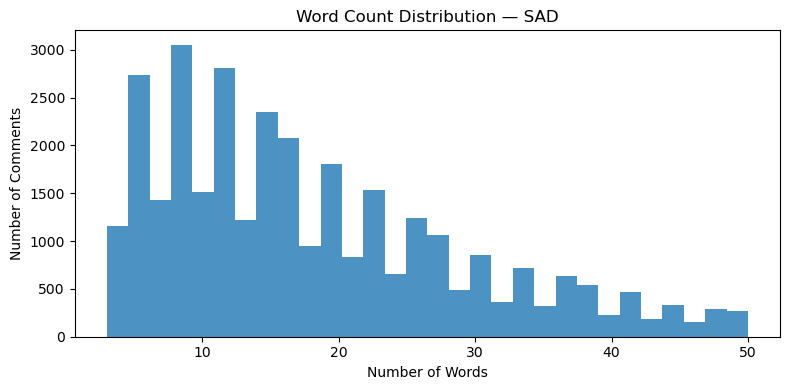

In [40]:
for label in ["HAPPY", "SAD"]:
    values = analysis_df.loc[
        (analysis_df["label"] == label) &
        (analysis_df["word_count"] <= 50),
        "word_count"
    ]

    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=30, alpha=0.8)

    plt.title(f"Word Count Distribution — {label}")
    plt.xlabel("Number of Words")
    plt.ylabel("Number of Comments")
    plt.tight_layout()
    plt.show()

In [41]:
analysis_df.to_csv(
    Path.cwd() / "outputs" / "snappfood_analysis_ready.csv",
    index=False,
    encoding="utf-8-sig"
)

<h2 style="color:#00BFC4;">Comment-Length Finding</h2>

<p>
Negative reviews were generally longer than positive reviews. SAD comments
contained an average of 21.41 words, while HAPPY comments contained 16.21
words. This suggests that dissatisfied customers tend to provide more detail
when explaining problems with their orders.
</p>

<h1 style="color:#FF1493;">Step 7: Word Frequency Analysis</h1>

<h2 style="color:#00BFC4;">Most Frequent Words by Sentiment</h2>

<p>
Useful words are counted separately in positive and negative reviews after
normalization and stopword removal.
</p>

In [42]:
from collections import Counter

happy_words = Counter(
    word
    for tokens in analysis_df.loc[
        analysis_df["label"] == "HAPPY", "tokens"
    ]
    for word in tokens
)

sad_words = Counter(
    word
    for tokens in analysis_df.loc[
        analysis_df["label"] == "SAD", "tokens"
    ]
    for word in tokens
)

happy_top20 = pd.DataFrame(
    happy_words.most_common(20),
    columns=["word", "frequency"]
)

sad_top20 = pd.DataFrame(
    sad_words.most_common(20),
    columns=["word", "frequency"]
)

print("Most frequent HAPPY words:")
display(happy_top20)

print("Most frequent SAD words:")
display(sad_top20)

Most frequent HAPPY words:


,word,frequency
0,عالی,12627
1,خیلی,11329
2,خوب,10101
3,غذا,6436
4,کیفیت,6250
5,خوشمزه,5466
6,ممنون,4679
7,رسید,4630
8,بسیار,3910
9,سفارش,3669


Most frequent SAD words:


,word,frequency
0,غذا,9169
1,خیلی,9092
2,کیفیت,8166
3,سفارش,7856
4,نبود,6224
5,اصلا,5763
6,سرد,5116
7,پیتزا,5021
8,بسیار,4705
9,بد,4295


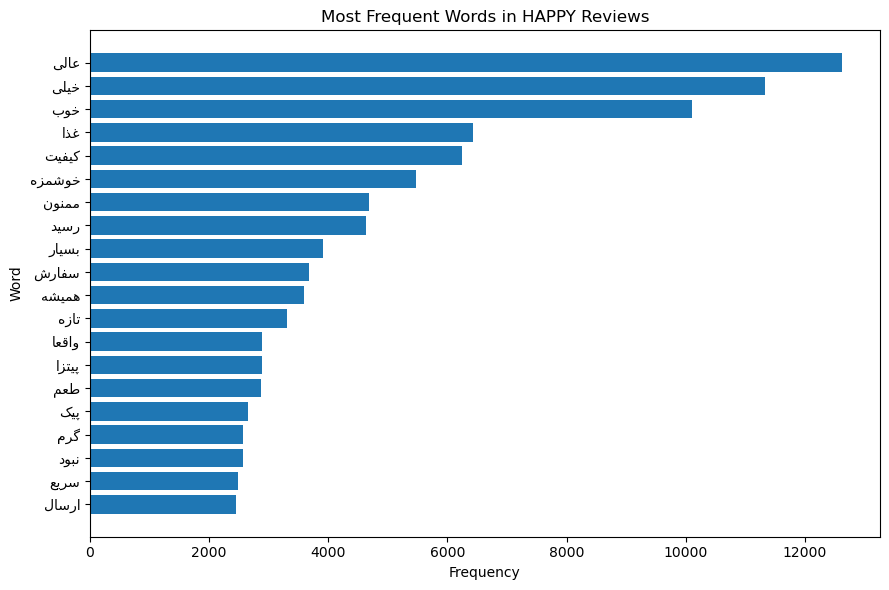

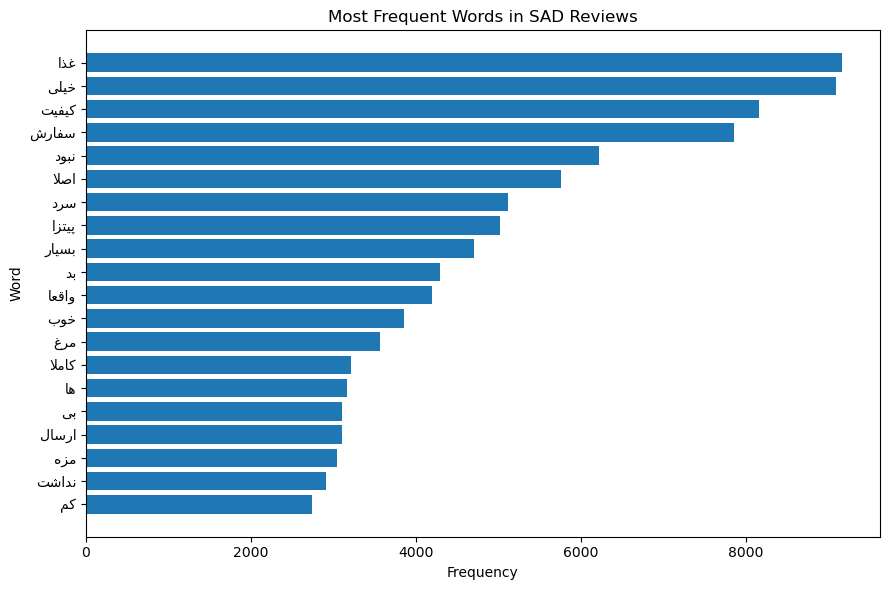

In [44]:
import arabic_reshaper
from bidi.algorithm import get_display

def persian_display(text):
    return get_display(arabic_reshaper.reshape(str(text)))

def plot_top_words(data, title):
    plot_data = data.sort_values("frequency")

    plt.figure(figsize=(9, 6))
    plt.barh(
        [persian_display(word) for word in plot_data["word"]],
        plot_data["frequency"]
    )

    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()

plot_top_words(
    happy_top20,
    "Most Frequent Words in HAPPY Reviews"
)

plot_top_words(
    sad_top20,
    "Most Frequent Words in SAD Reviews"
)

In [45]:
happy_top20.to_csv(
    Path.cwd() / "outputs" / "top_happy_words.csv",
    index=False,
    encoding="utf-8-sig"
)

sad_top20.to_csv(
    Path.cwd() / "outputs" / "top_sad_words.csv",
    index=False,
    encoding="utf-8-sig"
)

<h1 style="color:#FF1493;">Step 8: Sentiment Association Analysis</h1>

<h2 style="color:#00BFC4;">Identifying Words Strongly Associated with HAPPY and SAD Reviews</h2>

<p>
Raw frequency does not always indicate sentiment. Some words appear frequently
in both classes. A log-odds ratio is therefore calculated to identify words
that occur proportionally more often in one sentiment than the other.
</p>

In [46]:
# Words that describe the topic rather than the sentiment
neutral_words = {
    "غذا", "سفارش", "کیفیت", "پیتزا", "پیک", "ارسال",
    "مرغ", "طعم", "مزه", "ها", "خیلی", "بسیار",
    "واقعا", "کاملا", "همیشه", "اصلا"
}

all_words = set(happy_words) | set(sad_words)

association = pd.DataFrame({
    "word": list(all_words),
    "happy_count": [happy_words[word] for word in all_words],
    "sad_count": [sad_words[word] for word in all_words]
})

total_happy = sum(happy_words.values())
total_sad = sum(sad_words.values())

# Smoothed log-odds ratio
association["score"] = np.log(
    ((association["happy_count"] + 0.5) /
     (total_happy - association["happy_count"] + 0.5))
    /
    ((association["sad_count"] + 0.5) /
     (total_sad - association["sad_count"] + 0.5))
)

association["total_count"] = (
    association["happy_count"] + association["sad_count"]
)

# Keep meaningful and sufficiently common words
association = association[
    (association["total_count"] >= 50) &
    (~association["word"].isin(neutral_words)) &
    (association["word"].str.len() > 1)
].copy()

In [47]:
happy_associated = (
    association
    .sort_values("score", ascending=False)
    .head(20)
    [["word", "happy_count", "sad_count", "score"]]
)

sad_associated = (
    association
    .sort_values("score")
    .head(20)
    [["word", "happy_count", "sad_count", "score"]]
)

print("Words most associated with HAPPY reviews:")
display(happy_associated)

print("Words most associated with SAD reviews:")
display(sad_associated)

Words most associated with HAPPY reviews:


,word,happy_count,sad_count,score
18883,چسبید,77,0,5.327380
6401,دمتون,237,3,4.501757
22570,نظیره,53,1,3.858109
5010,نقص,79,3,3.406949
20430,ممنونم,1675,77,3.361432
19154,وخوشمزه,51,2,3.309177
1987,لذیذ,358,17,3.304359
5888,عالی,12627,704,3.200890
15057,منظم,75,4,3.103998
10343,بردم,125,7,3.101466


Words most associated with SAD reviews:


,word,happy_count,sad_count,score
16775,پشیمونم,1,62,-3.446055
19994,بدترین,13,514,-3.357687
23006,متاسفم,29,947,-3.187400
12780,آخرین,9,270,-3.065709
5134,آبروم,2,69,-3.041401
17869,افتضاح,59,1399,-2.876641
2705,انداختم,5,110,-2.716702
23071,حالم,3,65,-2.645642
11279,تاسف,8,155,-2.623092
22702,صفر,4,75,-2.536426


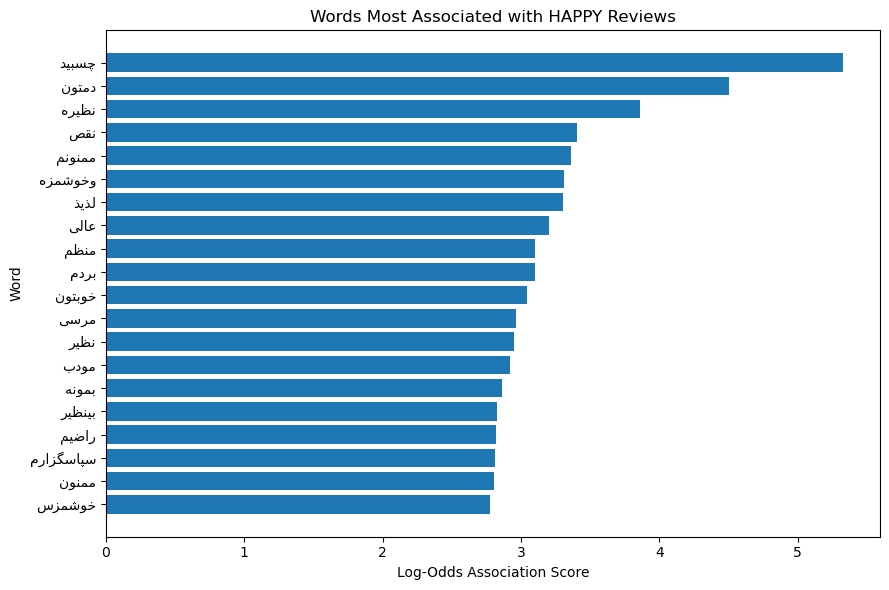

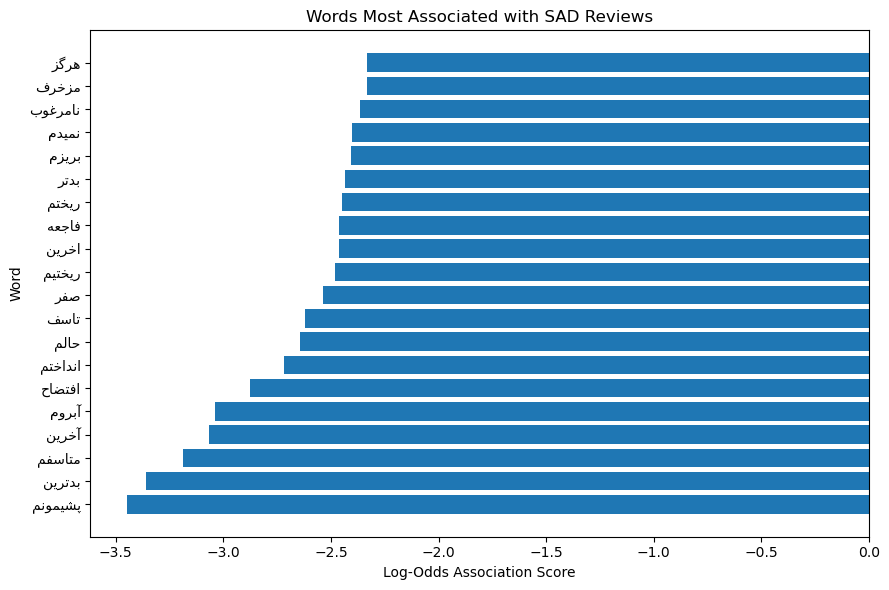

In [48]:
def plot_association(data, title):
    plot_data = data.sort_values("score")

    plt.figure(figsize=(9, 6))
    plt.barh(
        [persian_display(word) for word in plot_data["word"]],
        plot_data["score"]
    )

    plt.title(title)
    plt.xlabel("Log-Odds Association Score")
    plt.ylabel("Word")
    plt.tight_layout()
    plt.show()


plot_association(
    happy_associated,
    "Words Most Associated with HAPPY Reviews"
)

plot_association(
    sad_associated,
    "Words Most Associated with SAD Reviews"
)

In [49]:
happy_associated.to_csv(
    Path.cwd() / "outputs" / "happy_associated_words.csv",
    index=False,
    encoding="utf-8-sig"
)

sad_associated.to_csv(
    Path.cwd() / "outputs" / "sad_associated_words.csv",
    index=False,
    encoding="utf-8-sig"
)

<h1 style="color:#FF1493;">Step 9: Context and Phrase Analysis</h1>

<h2 style="color:#00BFC4;">Inspecting Words in Their Original Context</h2>

<p>
Individual words may have different meanings depending on the words around
them. Therefore, unexpected results are checked inside their original comments.
</p>

In [50]:
def show_word_examples(word, n=10):
    examples = df[
        df["normalized_comment"].str.contains(
            word, regex=False, na=False
        )
    ][["comment", "label"]]

    return examples.sample(
        min(n, len(examples)),
        random_state=42
    )

show_word_examples("نقص", 15)

,comment,label
31392,بی نظیر. پنج ستاره. بی نقص,HAPPY
15449,عاااااالی سریع و بدون نقص,HAPPY
41709,بسیار سریع و کامل و بدپن نقص به دستم رسید، ممنون,HAPPY
51028,با اختلاف بهترین غذا در بین رستوران‌ها و کتریتگ‌های منطقه کیفیت و حجم غذا بسیار خوب، دورچین و بسته بندی بی نقص,HAPPY
1429,سلام همیشه سوپر مارکت هاتون نقص دارن و‌هیچ وقت کامل سفارشو نمیارن,HAPPY
19827,عالی عالی!! ممنون که به توضیحات سفارش دقت می‌کنید کیفیت، حجم و ارسال همگی بی نقص,HAPPY
30523,مثل همیشه عالی بود. از خریدم کاملا راضی بودم. فقط اگر امکانش باشه گرم به دستمون برسه و شکلاتشم یه کم بیشتر کنید بی نقص میشه!,HAPPY
48671,به موقع و بی نقص اوردن,HAPPY
9622,سریع و دقیق و بدون نقص، ممنونم.,HAPPY
33216,تازه و عالی و بی نقص … موزها بی لک و مجلسی بودند. ممنونم و پایدار باشید.,HAPPY


In [51]:
show_word_examples("بردم", 10)

,comment,label
57353,ضمن عرض سلام و خسته نباشید به کلیه پرسنل و مدیریت P-S می‌خواستم بابت غذاهای خوب و با کیفیتی که از این رستوران خرید کردم تشکر کنم و بگم که واقعا در منطقه حرف اول رو در ارائه غذا و خدمات میزنن چون م...,HAPPY
24192,واقعا فوق العاده بوددد خیلی لذت بردم. حتما سفارش بدید,HAPPY
60141,سالاد شیرازی صیفیجاتش خوبه اما نا مزست کمی روغن زیتون گران کمی نعناع و آبغوره یا آبلیمو میتواند از سطح پایین به خوشمزه تغییرش بدهد قیمه خودش خوب بود و لذت بردم اما برنجشون رو نمیدونم چطور ….,HAPPY
61532,عالی بووود لذت بردم,HAPPY
50842,هر بار که این کیک محبوبم رو سفارش دادم پسرفت کیفیتش رو حس کردم.. از کوک بعیده این کیفیت نون پایین.. لایه‌های نون زیر خامه‌ها به شدت خشک و حجیم بود و خوردنش رسمأ سخت بود و خورد و پخش میشد.. حجم خام...,SAD
17538,غذاش عالیه گرم و خوش طعم. من که خیلی لذت بردم. ممنونم نامیا,HAPPY
43447,عالی بود واقعا لذت بردم,HAPPY
44298,کریسپی بیبی اسکوئید عالی سرخ شده بود و حجمش هم کاملا سیرم کرد و لذت بردم از بسته بندی شیک و به روزتون. مشخص هست که برای پذیرایی ارز مشتری ارزش قائل هستید,HAPPY
43096,واقعا خوشمزه و تازه بود من که لذت بردم,HAPPY
62656,عالی! هم سریع و گرم رسید و برخورد پیک خیلی خوب بود، هم غذا خیلی خوشمزه و با کیفیت بود. لذت بردم. ممنون,HAPPY


In [52]:
show_word_examples("بمونه", 10)

,comment,label
6632,طعم کباب بسیار عالی بود، امیدوارم کیفیت همینطور باقی بمونه. مشخص بود که کباب ذغالی درست شده.,HAPPY
15648,غذاهاشون خوب بود. داغ داغ رسید. فقط برای من یکم نمک کباب‌ها زیاد بود.. چنجه نرم و خوب بود.. میتونه بهتر هم بشه. کته خوب بود، بیشتر بمونه و ته دیگی‌تر بشه عالی میشه. کوبیده هم حجمش زیاد نبود اما خو...,HAPPY
50272,این مجموعه بسیار حرفه‌ای، دلسوز و باسلیقه هستند، عملا بهتر از خودم که برم میوه فروشی خرید کنم، انتخاب می‌کنند با قیمتی مناسب. در این سفارش هم، ۲۵۰ گرم پسته اشتباها زیادی فرستاده بودند، که در مقابل...,HAPPY
11915,اگر کیفیتش همینطوری بمونه عالیه,HAPPY
23446,خدا حفظتون کنه عالی عالی، هیچ جای تهران مرغ سوخاری شمارو نخوردم، حتی جاهایی که معروف هستن و خیلی شلوغن، به گرد پای شماهم نمیرسن، امیدوارم فروشتون روز به روز بیشتر بشه و کیفیت عالیتون ثابت بمونه، ی...,HAPPY
5700,غذا فوق العاده خوشمزه ممنون از رستوزان شنزار امیدوارم کیفیت همینجوری بمونه,HAPPY
41974,خدا به کسبتون برکت بده میوه عالی قیمت منصفانه ان قدر همه چی این هایپر میوه فوق العادست که آدم دلش می‌خواد تافت بزنه همینجوری بمونین کیفیت تمامی اقلام خرید من دقیقا مطابق با خواستم بود کمی دیر ارسا...,HAPPY
66595,مرسی از پیک اسنپ. پیتزا مثل همیشه با کیفیت و عالی بود و همه اینها به لطف وجدان کاری آلپارو هستش امیدوارم این کیفیت در آینده هم حفظ بشه و همچنان بهترین رستوران این منطقه باقی بمونه,HAPPY
37991,عالی بود، امیدوارم همیشه همینجوری با کیفیت بمونه.,HAPPY
50605,بسیار بسیار عالی بود کیفیت غذاها، امیدواریم همیشه به همین شکل باقی بمونه,HAPPY


In [53]:
show_word_examples("آخرین", 10)

,comment,label
904,"با اینکه توی سفارش تاکید کرده بودم شیرینی‌ها تازه باشه, شیرینی ها, مخصوصا دانمارکی, به شدت کهنه و مونده بود. آخرین باری بود که از اینجا چیزی سفارش دادم. ۳۲هزار تومن پول رو ریختم بیرون انگار! وجدان...",SAD
58412,مطمئنا اولین و آخرین بار بود,SAD
38248,کیفیت پاستا و پیتزا ضیعف بود ولی حجم آنها مناسب بود در کل آخرین خرید من از این مجموعه خواهد بود!,SAD
49839,اولین و آخرین بارمه از اینجا سفارش میدم. همین با تشکر,SAD
17064,اصلا خوب نبود آخرین خریدم بود از این شیرینی فروشی,SAD
55468,من همیشه از این رستوران سفارش میدادم ولى متاسفانه کیفیت غذاها افت کرده واین آخرین سفارشم بود,SAD
60645,یک ساعت و نیم انتظار برای یه ساندویچ ۱۵ سانتی. هر روز حجم کمتر، قیمت بالاتر و تاخیر بیشتر. آخرین سفارشم بود,SAD
42510,افتضاح بود غذا کاملا سرد رسید اولین و آخرین سفارشم از این رستوران خواهد بود,SAD
8601,اصلا اصلا کیفیت پیتزا خوب نبود پیتزا سبزیجات بیشتر نخود داشتغذا سرد بود … قارچ سوخاری فوق العاده بی مزه بوددددد ….. آخرین باری بود که از شما غذا میگیرررم اصلا راضی نبوددددم,SAD
54199,واقعا افتضاح بود. آخرین باری بود که از این رستوران سفارش می‌دهم. گوشت برگر خام بود، پنیری وجود نداشت، از سس باربیکیو هم خبری نبود. علاوه بر تمام این‌ها غذا بسیار سرد بود.,SAD


In [54]:
def make_bigrams(tokens):
    return [
        f"{tokens[i]} {tokens[i + 1]}"
        for i in range(len(tokens) - 1)
    ]

analysis_df["bigrams"] = analysis_df["tokens"].apply(make_bigrams)

In [55]:
happy_bigrams = Counter(
    phrase
    for phrases in analysis_df.loc[
        analysis_df["label"] == "HAPPY", "bigrams"
    ]
    for phrase in phrases
)

sad_bigrams = Counter(
    phrase
    for phrases in analysis_df.loc[
        analysis_df["label"] == "SAD", "bigrams"
    ]
    for phrase in phrases
)

happy_bigram_top20 = pd.DataFrame(
    happy_bigrams.most_common(20),
    columns=["bigram", "frequency"]
)

sad_bigram_top20 = pd.DataFrame(
    sad_bigrams.most_common(20),
    columns=["bigram", "frequency"]
)

print("Most frequent HAPPY bigrams:")
display(happy_bigram_top20)

print("Most frequent SAD bigrams:")
display(sad_bigram_top20)

Most frequent HAPPY bigrams:


,bigram,frequency
0,خیلی خوب,1962
1,بسته بندی,1605
2,سیب زمینی,1277
3,دستم رسید,1027
4,فوق العاده,1019
5,اسنپ فود,1009
6,بسیار عالی,1009
7,همیشه عالی,993
8,کیفیت غذا,918
9,خیلی خوشمزه,906


Most frequent SAD bigrams:


,bigram,frequency
0,سیب زمینی,2069
1,سفارش دادم,1869
2,بی کیفیت,1664
3,بسته بندی,1286
4,خوب نبود,1168
5,خیلی بد,1074
6,کیفیت غذا,1015
7,غذا سرد,1005
8,سفارش داده,981
9,اسنپ فود,843


In [56]:
def phrases_containing(word, counter, n=15):
    results = [
        (phrase, count)
        for phrase, count in counter.items()
        if word in phrase.split()
    ]

    return pd.DataFrame(
        sorted(results, key=lambda x: x[1], reverse=True)[:n],
        columns=["phrase", "frequency"]
    )

print("HAPPY phrases containing نقص:")
display(phrases_containing("نقص", happy_bigrams))

print("SAD phrases containing نقص:")
display(phrases_containing("نقص", sad_bigrams))

HAPPY phrases containing نقص:


,phrase,frequency
0,بی نقص,47
1,بدون نقص,23
2,نقص عالی,5
3,نقص دستم,3
4,نقص متشکرم,3
5,نقص ممنونم,2
6,نقص اوردن,2
7,نقص سریع,2
8,نقص بشه,2
9,نقص ممنون,2


SAD phrases containing نقص:


,phrase,frequency
0,بی نقص,1
1,نقص تحویل,1
2,فرداش نقص,1
3,نقص ها,1
4,کارشونو نقص,1
5,نقص انجام,1


<h2 style="color:#00BFC4;">Bigrams Associated with Each Sentiment</h2>

<p>
Two-word phrases are compared using a log-odds score. Positive scores indicate
association with HAPPY reviews, while negative scores indicate association
with SAD reviews.
</p>

In [57]:
all_bigrams = set(happy_bigrams) | set(sad_bigrams)

bigram_association = pd.DataFrame({
    "bigram": list(all_bigrams),
    "happy_count": [
        happy_bigrams[phrase] for phrase in all_bigrams
    ],
    "sad_count": [
        sad_bigrams[phrase] for phrase in all_bigrams
    ]
})

total_happy_bigrams = sum(happy_bigrams.values())
total_sad_bigrams = sum(sad_bigrams.values())

bigram_association["score"] = np.log(
    (
        (bigram_association["happy_count"] + 0.5) /
        (
            total_happy_bigrams
            - bigram_association["happy_count"]
            + 0.5
        )
    )
    /
    (
        (bigram_association["sad_count"] + 0.5) /
        (
            total_sad_bigrams
            - bigram_association["sad_count"]
            + 0.5
        )
    )
)

bigram_association["total_count"] = (
    bigram_association["happy_count"]
    + bigram_association["sad_count"]
)

# Keep phrases that occur often enough to be meaningful
bigram_association = bigram_association[
    bigram_association["total_count"] >= 30
]

In [58]:
happy_bigram_associated = (
    bigram_association
    .sort_values("score", ascending=False)
    .head(20)
    [["bigram", "happy_count", "sad_count", "score"]]
)

sad_bigram_associated = (
    bigram_association
    .sort_values("score")
    .head(20)
    [["bigram", "happy_count", "sad_count", "score"]]
)

print("Bigrams most associated with HAPPY reviews:")
display(happy_bigram_associated)

print("Bigrams most associated with SAD reviews:")
display(sad_bigram_associated)

Bigrams most associated with HAPPY reviews:


,bigram,happy_count,sad_count,score
334692,کل عالی,93,0,5.539188
32261,عالی عالی,343,2,5.231662
200829,خوشمزه سریع,68,0,5.227991
97857,حتما امتحان,66,0,5.198354
235639,همیشه سریع,65,0,5.183199
290636,عالی ممنونم,195,1,5.178454
5331,رسید خوشمزه,63,0,5.152184
212207,عالی بی,57,0,5.052912
290417,عالی چیز,54,0,4.999319
292478,تازه سریع,51,0,4.942692


Bigrams most associated with SAD reviews:


,bigram,happy_count,sad_count,score
150775,بد ترین,0,57,-4.437225
247753,خیلی افتضاح,0,54,-4.383635
255369,کل اصلا,0,51,-4.327010
165289,بدترین پیتزایی,0,50,-4.307399
124159,غذا افتضاح,0,48,-4.266986
141523,یکی بدترین,0,46,-4.224870
221793,بدترین غذایی,0,40,-4.086708
283754,مونده بی,0,37,-4.009741
285922,کاملا ناراضی,0,37,-4.009741
173696,بدمزه ترین,0,35,-3.954928


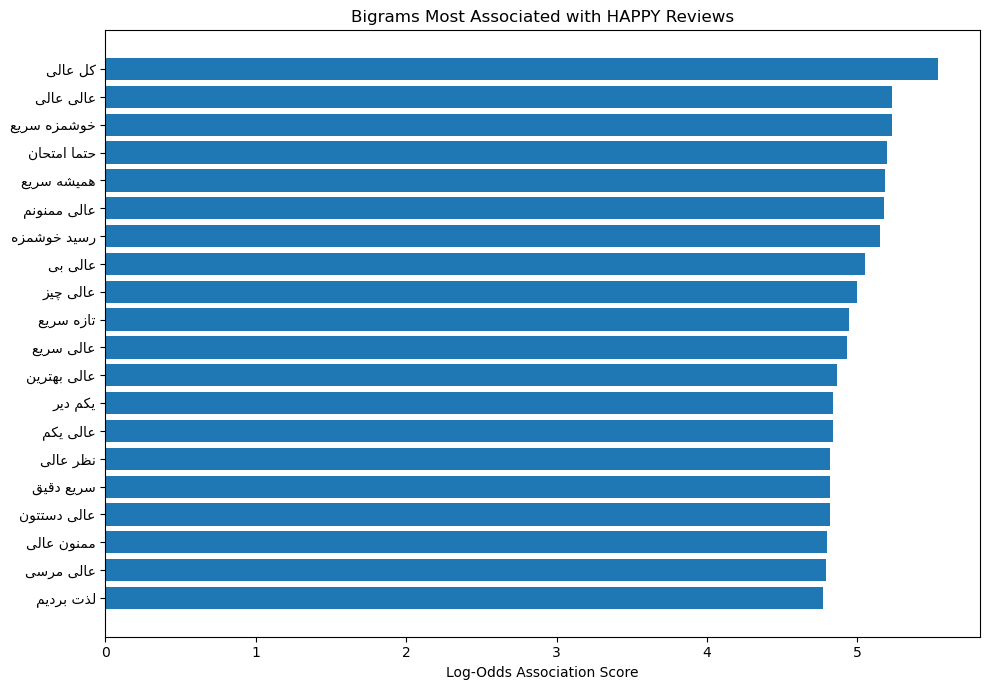

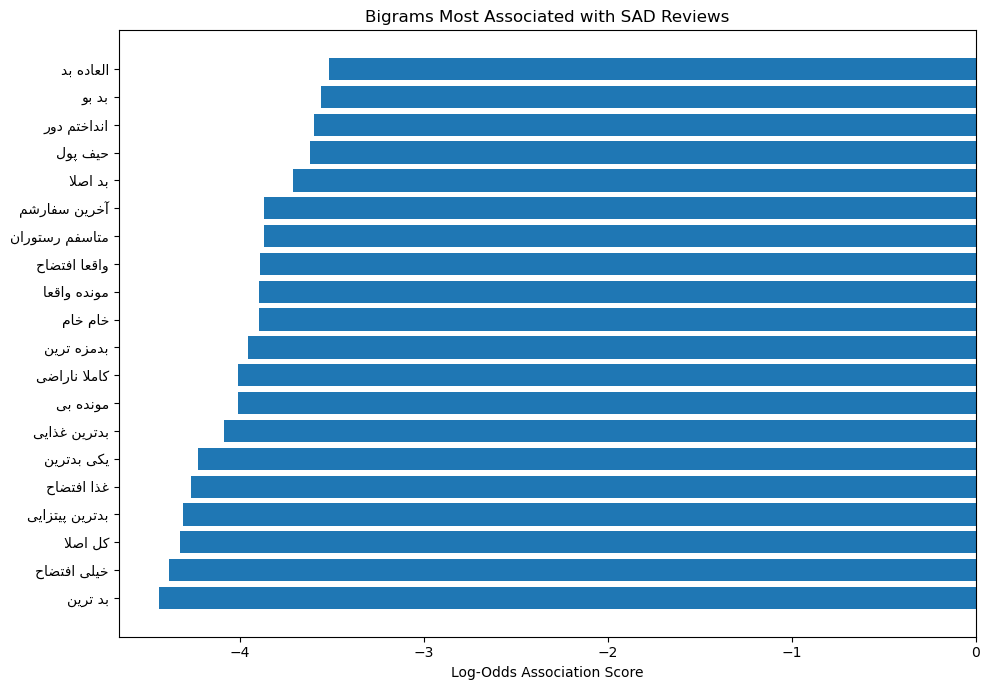

In [59]:
def plot_bigram_association(data, title):
    plot_data = data.sort_values("score")

    plt.figure(figsize=(10, 7))

    plt.barh(
        [
            persian_display(phrase)
            for phrase in plot_data["bigram"]
        ],
        plot_data["score"]
    )

    plt.title(title)
    plt.xlabel("Log-Odds Association Score")
    plt.tight_layout()
    plt.show()


plot_bigram_association(
    happy_bigram_associated,
    "Bigrams Most Associated with HAPPY Reviews"
)

plot_bigram_association(
    sad_bigram_associated,
    "Bigrams Most Associated with SAD Reviews"
)

In [60]:
happy_bigram_associated.to_csv(
    Path.cwd() / "outputs" / "happy_associated_bigrams.csv",
    index=False,
    encoding="utf-8-sig"
)

sad_bigram_associated.to_csv(
    Path.cwd() / "outputs" / "sad_associated_bigrams.csv",
    index=False,
    encoding="utf-8-sig"
)

<h1 style="color:#FF1493;">Step 9: Improved Phrase Analysis</h1>

<h2 style="color:#00BFC4;">Extracting True Adjacent Bigrams</h2>

<p>
Bigrams are extracted from the normalized comments before stopword removal.
This prevents words that were not originally adjacent from being incorrectly
joined together.
</p>

In [61]:
def exact_bigrams(text):
    words = text.split()
    return [
        f"{first} {second}"
        for first, second in zip(words, words[1:])
    ]

analysis_df["exact_bigrams"] = (
    analysis_df["normalized_comment"].apply(exact_bigrams)
)

In [62]:
happy_bigram_docs = Counter()
sad_bigram_docs = Counter()

for phrases in analysis_df.loc[
    analysis_df["label"] == "HAPPY", "exact_bigrams"
]:
    happy_bigram_docs.update(set(phrases))

for phrases in analysis_df.loc[
    analysis_df["label"] == "SAD", "exact_bigrams"
]:
    sad_bigram_docs.update(set(phrases))

In [63]:
def meaningful_bigram(phrase):
    first, second = phrase.split()

    return (
        len(first) > 1
        and len(second) > 1
        and not (first in stopwords and second in stopwords)
    )

<h2 style="color:#00BFC4;">Statistically Reliable Phrase Association</h2>

<p>
A weighted log-odds z-score is used to identify phrases that differ reliably
between positive and negative comments. This method gives less importance to
rare phrases with insufficient evidence.
</p>

In [64]:
all_bigrams = set(happy_bigram_docs) | set(sad_bigram_docs)

bigram_results = pd.DataFrame({
    "bigram": list(all_bigrams)
})

bigram_results["happy_docs"] = bigram_results["bigram"].map(
    happy_bigram_docs
).fillna(0)

bigram_results["sad_docs"] = bigram_results["bigram"].map(
    sad_bigram_docs
).fillna(0)

happy_total = (analysis_df["label"] == "HAPPY").sum()
sad_total = (analysis_df["label"] == "SAD").sum()

a = bigram_results["happy_docs"] + 0.5
b = happy_total - bigram_results["happy_docs"] + 0.5
c = bigram_results["sad_docs"] + 0.5
d = sad_total - bigram_results["sad_docs"] + 0.5

bigram_results["log_odds"] = np.log((a / b) / (c / d))
bigram_results["standard_error"] = np.sqrt(
    1 / a + 1 / b + 1 / c + 1 / d
)

bigram_results["z_score"] = (
    bigram_results["log_odds"]
    / bigram_results["standard_error"]
)

bigram_results["total_docs"] = (
    bigram_results["happy_docs"]
    + bigram_results["sad_docs"]
)

bigram_results["happy_percentage"] = (
    bigram_results["happy_docs"]
    / bigram_results["total_docs"]
    * 100
).round(1)

bigram_results = bigram_results[
    (bigram_results["total_docs"] >= 50)
    & bigram_results["bigram"].apply(meaningful_bigram)
].copy()

In [65]:
happy_phrases = (
    bigram_results
    .sort_values("z_score", ascending=False)
    .head(20)
    [[
        "bigram",
        "happy_docs",
        "sad_docs",
        "happy_percentage",
        "z_score"
    ]]
)

sad_phrases = (
    bigram_results
    .sort_values("z_score")
    .head(20)
    [[
        "bigram",
        "happy_docs",
        "sad_docs",
        "happy_percentage",
        "z_score"
    ]]
)

print("Phrases associated with HAPPY reviews:")
display(happy_phrases)

print("Phrases associated with SAD reviews:")
display(sad_phrases)

Phrases associated with HAPPY reviews:


,bigram,happy_docs,sad_docs,happy_percentage,z_score
152961,عالی بود,5410,381,93.4,52.291024
6014,خوب بود,5867,1550,79.1,49.231359
246267,خوشمزه بود,2403,247,90.7,34.651821
34722,مثل همیشه,2170,292,88.1,32.681874
87882,خیلی خوب,1889,247,88.4,30.459449
306733,به موقع,1693,164,91.2,28.866179
273452,ممنون از,1334,94,93.4,25.066187
34365,بود ممنون,1107,46,96.0,21.299125
102606,همیشه عالی,986,55,94.7,20.960389
60617,بسیار عالی,991,43,95.8,20.278821


Phrases associated with SAD reviews:


,bigram,happy_docs,sad_docs,happy_percentage,z_score
107355,بد بود,158,1738,8.3,-29.414722
21187,بی کیفیت,87,1574,5.2,-26.731003
93675,سرد بود,596,1815,24.7,-24.229353
10123,خیلی بد,112,1030,9.8,-22.601400
117731,سفارش دادم,699,1782,28.2,-21.577384
81849,پایین بود,76,955,7.4,-21.498310
189112,خوب نبود,335,1132,22.8,-19.944940
129824,بعد از,231,966,19.3,-19.840781
71376,مونده بود,174,868,16.7,-19.616027
108357,کاملا سرد,136,807,14.4,-19.451775


In [66]:
def compare_phrases(phrases):
    return (
        bigram_results[
            bigram_results["bigram"].isin(phrases)
        ]
        .sort_values("z_score", ascending=False)
    )

compare_phrases([
    "سیب زمینی",
    "خیلی خوب",
    "خیلی بد",
    "خوب نبود",
    "بی کیفیت",
    "غذا سرد",
    "فوق العاده",
    "راضی بودم",
    "راضی نبودم"
])

,bigram,happy_docs,sad_docs,log_odds,standard_error,z_score,total_docs,happy_percentage
87882,خیلی خوب,1889,247,2.072426,0.068039,30.459449,2136,88.4
270411,راضی بودم,777,216,1.285908,0.077225,16.651410,993,78.2
256227,فوق العاده,986,603,0.493635,0.052248,9.447977,1589,62.1
283621,سیب زمینی,1163,1818,-0.475652,0.038338,-12.406952,2981,39.0
291142,راضی نبودم,66,681,-2.354050,0.128699,-18.291171,747,8.8
161166,غذا سرد,219,911,-1.453109,0.075575,-19.227259,1130,19.4
189112,خوب نبود,335,1132,-1.249176,0.062631,-19.944940,1467,22.8
10123,خیلی بد,112,1030,-2.250861,0.099589,-22.601400,1142,9.8
21187,بی کیفیت,87,1574,-2.943195,0.110104,-26.731003,1661,5.2


In [67]:
def show_examples(text, n=10):
    matches = analysis_df[
        analysis_df["normalized_comment"].str.contains(
            text,
            regex=False,
            na=False
        )
    ][["comment", "label"]]

    return matches.sample(
        min(n, len(matches)),
        random_state=42
    )

show_examples("نقص", 15)

,comment,label
31392,بی نظیر. پنج ستاره. بی نقص,HAPPY
15449,عاااااالی سریع و بدون نقص,HAPPY
41709,بسیار سریع و کامل و بدپن نقص به دستم رسید، ممنون,HAPPY
51028,با اختلاف بهترین غذا در بین رستوران‌ها و کتریتگ‌های منطقه کیفیت و حجم غذا بسیار خوب، دورچین و بسته بندی بی نقص,HAPPY
1429,سلام همیشه سوپر مارکت هاتون نقص دارن و‌هیچ وقت کامل سفارشو نمیارن,HAPPY
19827,عالی عالی!! ممنون که به توضیحات سفارش دقت می‌کنید کیفیت، حجم و ارسال همگی بی نقص,HAPPY
30523,مثل همیشه عالی بود. از خریدم کاملا راضی بودم. فقط اگر امکانش باشه گرم به دستمون برسه و شکلاتشم یه کم بیشتر کنید بی نقص میشه!,HAPPY
48671,به موقع و بی نقص اوردن,HAPPY
9622,سریع و دقیق و بدون نقص، ممنونم.,HAPPY
33216,تازه و عالی و بی نقص … موزها بی لک و مجلسی بودند. ممنونم و پایدار باشید.,HAPPY


In [68]:
def bigrams_containing(word, counter, n=15):
    results = [
        (phrase, count)
        for phrase, count in counter.items()
        if word in phrase.split()
    ]

    return pd.DataFrame(
        sorted(
            results,
            key=lambda item: item[1],
            reverse=True
        )[:n],
        columns=["bigram", "document_count"]
    )

print("HAPPY phrases containing نقص:")
display(bigrams_containing("نقص", happy_bigram_docs))

print("SAD phrases containing نقص:")
display(bigrams_containing("نقص", sad_bigram_docs))

HAPPY phrases containing نقص:


,bigram,document_count
0,بی نقص,47
1,بدون نقص,23
2,نقص بود,10
3,نقص و,10
4,نقص به,3
5,نقص بوده,2
6,نقص اوردن,2
7,نقص بشه,2
8,نقص ممنون,2
9,نقص میشه,2


SAD phrases containing نقص:


,bigram,document_count
0,نقص تحویل,1
1,بی نقص,1
2,نقص انجام,1
3,فرداش نقص,1
4,نقص ها,1
5,با نقص,1
